# Analyse Géologique Automatisée avec TerraTorch et Prithvi EO

## Introduction
Ce notebook Colab présente une approche innovante pour l'analyse géologique en utilisant des modèles de Deep Learning avancés, spécifiquement le modèle Prithvi EO de la NASA/IBM, via la bibliothèque TerraTorch. L'objectif est de démontrer comment ces outils peuvent être exploités pour extraire des informations géologiques complexes à partir d'images satellite, sans nécessiter d'expertise approfondie en géologie ou en télédétection.

Nous allons automatiser les étapes clés de l'analyse, de l'acquisition des données à la segmentation des unités géologiques, en passant par l'extraction de caractéristiques et la visualisation des résultats. Cette méthode permet une exploration rapide et efficace des zones d'intérêt, en particulier dans les régions où les données géologiques sont rares ou difficiles d'accès.

## Objectifs du Notebook
*   **Acquisition et Préparation des Données**: Télécharger et prétraiter des images satellite Landsat 8 pour une zone d'étude définie.
*   **Extraction de Caractéristiques Avancées**: Utiliser le modèle Prithvi EO via TerraTorch pour extraire des caractéristiques sémantiques et géologiques des images.
*   **Segmentation Géologique**: Appliquer des techniques de clustering non supervisé sur les caractéristiques extraites pour identifier et délimiter les unités géologiques.
*   **Visualisation et Analyse**: Générer des cartes interactives et des graphiques pour visualiser les unités géologiques identifiées et analyser leur distribution spatiale et surfacique.
*   **Quantification des Unités**: Calculer l'aire de chaque unité géologique identifiée et visualiser sa distribution en pourcentage.

## Méthodologie
1.  **Initialisation de l'environnement**: Installation des bibliothèques nécessaires et authentification Earth Engine.
2.  **Définition de la Zone d'Étude (ROI)**: Spécification des coordonnées géographiques d'une zone d'intérêt.
3.  **Acquisition des Données Satellite**: Téléchargement d'images Landsat 8 filtrées et masquées pour les nuages.
4.  **Inférence Prithvi**: Passage des images satellite à travers le modèle Prithvi EO pour générer une carte de caractéristiques multi-dimensionnelles.
5.  **Réduction de Dimensionalité (PCA)**: Application de l'Analyse en Composantes Principales (PCA) pour réduire la complexité des caractéristiques et créer une carte géologique visualisable en RGB.
6.  **Clustering Hiérarchique**: Utilisation d'un algorithme de clustering pour regrouper les pixels ayant des caractéristiques similaires en unités géologiques discrètes.
7.  **Visualisation Interactive**: Affichage des résultats sur une carte interactive Folium et sur des graphiques statistiques (histogrammes, diagrammes circulaires).

## Outils et Bibliothèques Utilisés
*   **Earth Engine (ee)**: Plateforme de Google pour l'analyse géospatiale à grande échelle, utilisée pour l'accès aux images satellite.
*   **geemap**: Une bibliothèque Python qui facilite l'interaction avec Earth Engine et la visualisation de données géospatiales.
*   **TerraTorch**: Une bibliothèque PyTorch qui simplifie l'intégration et l'utilisation des modèles de la NASA/IBM (comme Prithvi EO) pour la télédétection.
*   **PyTorch**: Framework de Deep Learning utilisé par TerraTorch pour l'inférence du modèle Prithvi.
*   **Scikit-learn (sklearn)**: Bibliothèque d'apprentissage automatique pour la PCA et les algorithmes de clustering.
*   **Matplotlib et Seaborn**: Bibliothèques de visualisation Python pour la création de graphiques statiques.
*   **Folium**: Bibliothèque Python pour la création de cartes interactives basées sur Leaflet.js.

### Utilisation des Outils
Nous utiliserons `geemap` et `ee` pour récupérer et prétraiter les données Landsat. `TerraTorch` permettra de charger et d'exécuter le modèle `Prithvi EO` afin d'obtenir des caractéristiques de l'image. Ensuite, `scikit-learn` sera utilisé pour des opérations de réduction de dimensionnalité et de clustering sur ces caractéristiques. Enfin, `matplotlib`, `seaborn` et `folium` serviront à visualiser les résultats, y compris la carte géologique segmentée et les statistiques d'aire des unités.

In [ ]:
# ====================================================
# CELLULE 1: Installation des dépendances (AVEC TERRATORCH)
# ====================================================
!pip install geemap earthengine-api scikit-learn rasterio geopandas shapely folium matplotlib seaborn terratorch torch -q

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import rasterio
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from terratorch.models import EncoderDecoderFactory # Updated import
from terratorch import BACKBONE_REGISTRY # Added import
import warnings
warnings.filterwarnings('ignore')

# Initialisation Earth Engine
try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize(project='geocongoai-api')

print("✅ TerraTorch et dépendances installés")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

✅ TerraTorch et dépendances installés
PyTorch: 2.10.0+cpu, CUDA: False


### Définition des Couleurs Partagées
Ce bloc de code initialise une liste de 20 couleurs distinctes à partir de la palette `tab20` de Matplotlib. Cette liste sera utilisée de manière cohérente pour colorer les différentes unités géologiques à la fois sur la carte interactive et dans les graphiques, garantissant ainsi une correspondance visuelle parfaite entre toutes les représentations.

In [ ]:
# Define a shared list of tab20 colors for consistent visualization
shared_tab20_colors = [plt.cm.tab20(i) for i in range(20)]
print("✅ Shared tab20 colors defined for consistent visualization.")

✅ Shared tab20 colors defined for consistent visualization.


### Définition de la Zone d'Intérêt
Ce code définit une zone d'étude spécifique au Congo à l'aide de coordonnées géographiques. Il initialise ensuite une carte interactive avec `geemap` et `folium`, centre la vue sur la zone définie et ajoute un marqueur rouge pour la visualiser. Cela permet de s'assurer que toutes les opérations suivantes sont concentrées sur la région d'intérêt.

In [ ]:
# ====================================================
# CELLULE 2: Définir votre zone d'étude (CONGO)
# ====================================================
# Coordonnées pour zone géologique au Congo
roi = ee.Geometry.Rectangle([15.0, -5.0, 16.0, -4.0])

# Visualisation interactive
Map = geemap.Map(basemap='Esri.WorldImagery') # Initialiser avec une basemap satellite qui ne nécessite pas de clé API Google
Map.centerObject(roi, 8)
Map.addLayer(roi, {'color': 'red'}, 'Zone d\'étude')
Map

print("📍 Zone d'étude définie")

📍 Zone d'étude définie


### Acquisition et Prétraitement des Données Landsat 8
Ce bloc de code gère l'acquisition d'images satellite Landsat 8 depuis la plateforme Google Earth Engine. Il filtre les images par date et par la zone d'étude définie précédemment. Une fonction de masquage des nuages est appliquée pour améliorer la qualité des données. Enfin, il sélectionne 6 bandes spectrales spécifiques (`SR_B2` à `SR_B7`) qui sont pertinentes pour le modèle Prithvi EO.

In [ ]:
# ====================================================
# CELLULE 3: Acquisition des données Landsat
# ====================================================
def mask_clouds(image):
    """Masquage des nuages Landsat 8"""
    qa = image.select('QA_PIXEL')
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0)
    return image.updateMask(cloud_mask)

# Récupération des images
collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
              .filterDate('2020-01-01', '2023-12-31')
              .filterBounds(roi)
              .map(mask_clouds))

image = collection.median().clip(roi)

# Bandes pour Prithvi (Bleu, Vert, Rouge, NIR, SWIR1, SWIR2)
bands_prithvi = ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
image_prithvi = image.select(bands_prithvi)

print("✅ Image Landsat 8 préparée avec 6 bandes spectrales")

✅ Image Landsat 8 préparée avec 6 bandes spectrales


### Exportation de l'Image Landsat Prétraitée
Ce code exporte l'image Landsat 8 sélectionnée (contenant les 6 bandes spectrales pour Prithvi) sous forme de fichier TIFF local. L'exportation est effectuée avec une échelle de 120 mètres par pixel pour optimiser la taille du fichier tout en conservant une résolution suffisante pour l'analyse. Ce fichier TIFF sera ensuite utilisé comme entrée pour le modèle Prithvi.

In [ ]:
# ====================================================
# CELLULE 4: Export de l'image
# ====================================================
geemap.ee_export_image(
    image_prithvi,
    'landsat_prithvi.tif',
    scale=120, # Increased scale further to reduce file size
    region=roi,
    file_per_band=False
)

print("✅ Image exportée: landsat_prithvi.tif")

Generating URL ...
Please wait ...
Data downloaded to /content/landsat_prithvi.tif
✅ Image exportée: landsat_prithvi.tif


### Chargement du Modèle Prithvi EO
Ce bloc charge le modèle de Deep Learning Prithvi EO v2_300 via la bibliothèque TerraTorch. Ce modèle, conçu par la NASA/IBM, est un encodeur puissant capable d'extraire des caractéristiques sémantiques riches à partir d'images satellite. `in_chans=6` indique que le modèle attend 6 bandes spectrales en entrée, correspondant aux bandes Landsat que nous avons préparées. `pretrained=True` télécharge automatiquement les poids pré-entraînés du modèle, optimisés pour la télédétection.

In [ ]:
model_prithvi = BACKBONE_REGISTRY.build(
    "prithvi_eo_v2_300",    # Corrected model name
    num_frames=1,           # Single image
    in_chans=6,             # 6 spectral bands
    pretrained=True         # Auto-download weights
)

model_prithvi.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_prithvi = model_prithvi.to(device)

print(f"✅ Model loaded on {device}")

✅ Model loaded on cpu


### Inférence Prithvi et Extraction des Caractéristiques Géologiques
Ce code effectue l'inférence avec le modèle Prithvi EO. Il charge l'image TIFF exportée précédemment, la normalise et la convertit en un tenseur PyTorch. Le modèle `model_prithvi` traite ensuite ce tenseur pour extraire des caractéristiques. Le code inclut une logique pour gérer différentes formes de sortie du modèle, typiques des architectures de type Vision Transformer, et prépare les caractéristiques extraites pour les étapes d'analyse ultérieures.

In [ ]:
# ====================================================
# CELLULE 6: INFÉRENCE PRITHVI AVEC TERRATORCH
# ====================================================
# Lecture de l'image
import rasterio
import torch
import numpy as np

print("📂 Lecture de l'image satellite...")
with rasterio.open('landsat_prithvi.tif') as src:
    img_data = src.read()
    bounds = src.bounds
    profile = src.profile

print(f"✅ Image chargée: {img_data.shape}")
print(f"📍 Étendue: {bounds}")

# Normalisation
print("\n🔄 Prétraitement des données...")
img_data = img_data.astype(np.float32)
img_data = np.clip(img_data, 0, 20000) / 10000.0
print(f"   Normalisation: valeurs entre {img_data.min():.2f} et {img_data.max():.2f}")

# Conversion en tenseur PyTorch
input_tensor = torch.from_numpy(img_data).float().unsqueeze(0).to(device)

print(f"   Tenseur d'entrée: {input_tensor.shape}")
print("   (TerraTorch va gérer automatiquement les patches du Vision Transformer)")

# Inférence - Extraction des caractéristiques géologiques
print("\n🧠 Inférence Prithvi en cours...")
print("   (Cela peut prendre quelques secondes...)")
with torch.no_grad():
    output = model_prithvi(input_tensor)

    # Gestion intelligente de la sortie
    if isinstance(output, (list, tuple)):
        print(f"   ⚠️ Le modèle a retourné {len(output)} éléments")
        # Chercher le tenseur avec la plus grande dimension
        best_candidate = None
        max_dims = 0
        for i, elem in enumerate(output):
            if hasattr(elem, 'shape') and len(elem.shape) > max_dims:
                max_dims = len(elem.shape)
                best_candidate = elem
                print(f"   - Élément {i}: shape {elem.shape}")
        features = best_candidate if best_candidate is not None else output[0]
    else:
        features = output

print(f"\n✅ Caractéristiques extraites avec succès!")
print(f"📊 Shape final: {features.shape}")

# Si c'est un tenseur 4D [B, C, H, W], on peut le manipuler directement
if len(features.shape) == 4:
    print("🎯 Format: [Batch, Canaux, Hauteur, Largeur]")
    feature_map = features[0].cpu().numpy()
    print(f"   - Carte de caractéristiques: {feature_map.shape}")
elif len(features.shape) == 3:
    print("🎯 Format: [Batch, Tokens, Dimensions]")
    print("   - Format Vision Transformer (tokens)")

📂 Lecture de l'image satellite...
✅ Image chargée: (6, 929, 929)
📍 Étendue: BoundingBox(left=14.998990635886829, bottom=-5.000741523636552, right=16.00043251462327, top=-3.99929964490011)

🔄 Prétraitement des données...
   Normalisation: valeurs entre 0.76 et 2.00
   Tenseur d'entrée: torch.Size([1, 6, 929, 929])
   (TerraTorch va gérer automatiquement les patches du Vision Transformer)

🧠 Inférence Prithvi en cours...
   (Cela peut prendre quelques secondes...)
   ⚠️ Le modèle a retourné 24 éléments
   - Élément 0: shape torch.Size([1, 3365, 1024])

✅ Caractéristiques extraites avec succès!
📊 Shape final: torch.Size([1, 3365, 1024])
🎯 Format: [Batch, Tokens, Dimensions]
   - Format Vision Transformer (tokens)


### Traitement des Caractéristiques TerraTorch
Ce bloc de code est crucial pour adapter la sortie du modèle Prithvi (qui est souvent sous forme de 'tokens' pour les Vision Transformers) à une grille de caractéristiques 2D interprétable. Il gère intelligemment les différentes dimensions de sortie du modèle et les restructure en une `feature_grid`. Cette grille représente les caractéristiques extraites pour chaque 'pixel géologique' de la zone d'étude, prête pour la PCA et le clustering.

In [ ]:
# ====================================================
# CELLULE 7: TRAITEMENT DES CARACTÉRISTIQUES TERRATORCH
# ====================================================
# TerraTorch peut retourner différentes formes selon la configuration
# Gestion adaptative des features
if len(features.shape) == 4:
    # Format [Batch, Canaux, Hauteur, Largeur]
    print("📊 Format: Carte de caractéristiques 2D")
    feature_map = features[0].cpu().numpy()
    h, w = feature_map.shape[1], feature_map.shape[2]

    # Réorganisation pour visualisation
    feature_flat = feature_map.reshape(feature_map.shape[0], -1).T
    grid_size = int(np.sqrt(feature_flat.shape[0]))
    feature_grid = feature_flat[:grid_size*grid_size, :].reshape(grid_size, grid_size, -1)

elif len(features.shape) == 3:
    # Format [Batch, Tokens, Dimensions]
    print("📊 Format: Tokens du Vision Transformer")
    tokens = features[0].cpu().numpy()  # (197, 768) ou similaire

    # Ignorer le token CLS (premier token)
    patch_tokens = tokens[1:, :]  # (196, 768)
    grid_size = int(np.sqrt(patch_tokens.shape[0]))
    feature_grid = patch_tokens.reshape(grid_size, grid_size, -1)

else:
    print(f"📊 Format spécial TerraTorch: {features.shape}")
    # Tentative de réorganisation adaptative
    feature_flat = features[0].cpu().numpy()
    if len(feature_flat.shape) > 1:
        grid_size = int(np.sqrt(feature_flat.shape[0]))
        feature_grid = feature_flat[:grid_size*grid_size, :].reshape(grid_size, grid_size, -1)
    else:
        grid_size = 14  # Valeur par défaut
        feature_grid = feature_flat.reshape(1, 1, -1).repeat(grid_size, axis=0).repeat(grid_size, axis=1)

print(f"✅ Grille de caractéristiques: {feature_grid.shape}")

📊 Format: Tokens du Vision Transformer
✅ Grille de caractéristiques: (58, 58, 1024)


### Génération de la Carte Géologique RGB (Visualisation)
Ce code applique une Analyse en Composantes Principales (PCA) sur les caractéristiques extraites par Prithvi. La PCA réduit la dimensionnalité des données tout en conservant la variance maximale, permettant de représenter les caractéristiques les plus importantes en trois composantes. Ces trois composantes sont ensuite normalisées et converties en une image RGB (`geological_map`), offrant une visualisation couleur de la géologie identifiée par le modèle. Chaque couleur dans cette carte représente une combinaison unique des caractéristiques géologiques.

In [ ]:
# ====================================================
# CELLULE 8: GÉNÉRATION DE LA CARTE GÉOLOGIQUE RGB
# ====================================================
# PCA pour visualisation en couleurs
pca = PCA(n_components=3)
features_flat = feature_grid.reshape(-1, feature_grid.shape[-1])
features_rgb = pca.fit_transform(features_flat)

# Normalisation pour affichage
features_rgb = features_rgb - features_rgb.min(axis=0)
features_rgb = features_rgb / (features_rgb.max(axis=0) + 1e-8)
features_rgb = (features_rgb * 255).astype(np.uint8)

# Carte géologique générée par Prithvi via TerraTorch
geological_map = features_rgb.reshape(grid_size, grid_size, 3)

print("✅ Carte géologique générée avec succès")
print(f"   Résolution: {grid_size}x{grid_size} pixels géologiques")

✅ Carte géologique générée avec succès
   Résolution: 58x58 pixels géologiques


### Visualisation Comparative des Cartes
Ce bloc génère trois visualisations côte à côte pour comparer la carte géologique générée par Prithvi avec les images satellite originales. Il affiche:
1.  **La carte géologique générée par Prithvi (RGB)**, montrant les différentes formations identifiées par l'IA.
2.  **L'image satellite en vraies couleurs (RGB)**, servant de référence visuelle du terrain.
3.  **Une image en fausses couleurs (SWIR-NIR-Rouge)**, qui met en évidence certaines caractéristiques végétales et hydrologiques, utile pour l'interprétation.

Des fonctions d'aide sont incluses pour normaliser les bandes spectrales, garantissant un affichage optimal. La carte géologique est redimensionnée pour correspondre à la résolution des caractéristiques extraites par Prithvi.

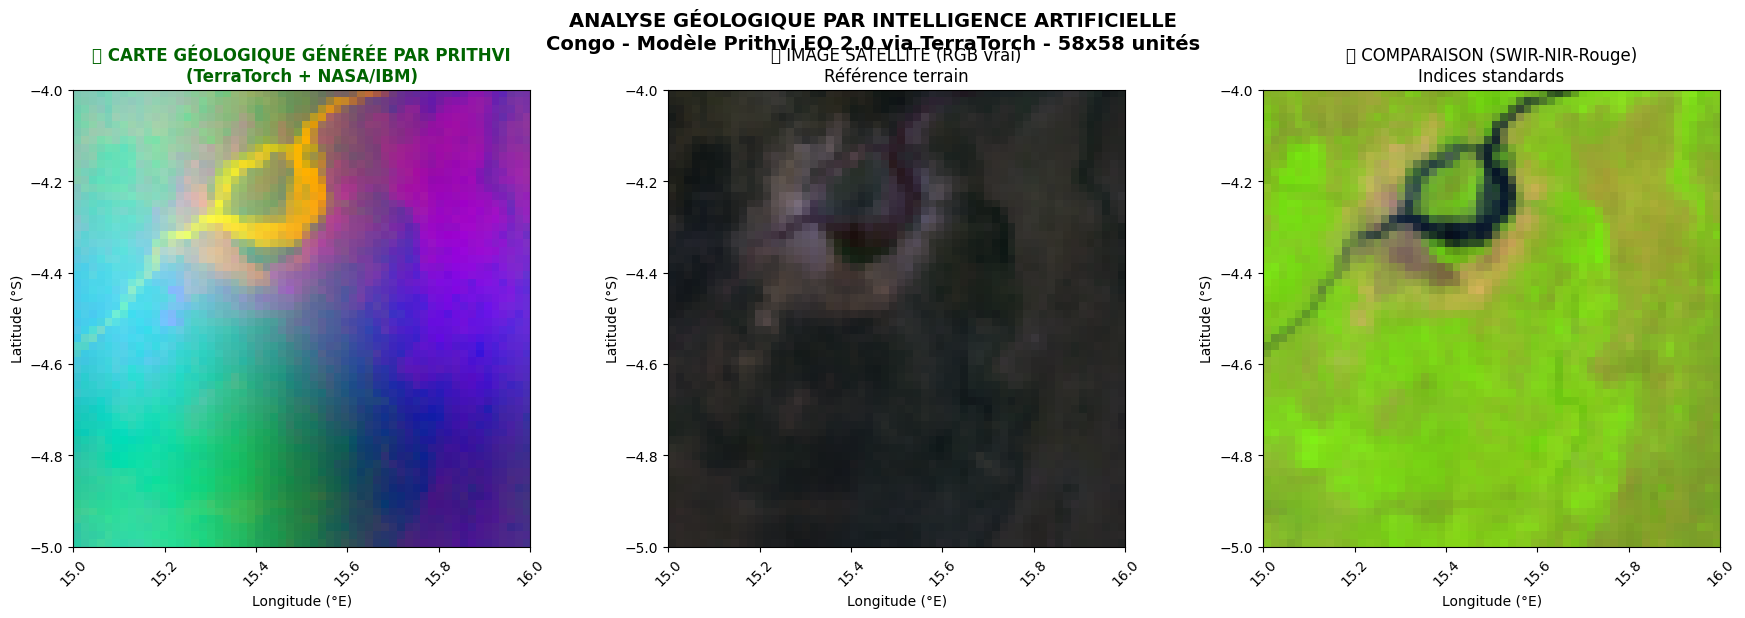


📊 INTERPRÉTATION DE LA CARTE GÉOLOGIQUE
• Chaque couleur = une signature géologique unique
• Zones homogènes = formations rocheuses similaires
• Contrastes nets = failles ou contacts lithologiques
• Gradients = zones d'altération progressive

💡 TerraTorch simplifie l'utilisation de Prithvi
   sans sacrifier la qualité de l'analyse géologique!


In [ ]:
from skimage.transform import resize

# Helper function to normalize bands for display
def normalize_band_for_display(band):
    min_val = band.min()
    max_val = band.max()
    if max_val > min_val:
        return (band - min_val) / (max_val - min_val)
    return np.zeros_like(band) # Return black if no variation

# Préparation des images de référence
# True color (RGB): SR_B4 (Red), SR_B3 (Green), SR_B2 (Blue)
# Corresponding img_data indices: 2 (B4), 1 (B3), 0 (B2)
red_band_rgb = normalize_band_for_display(img_data[2])
green_band_rgb = normalize_band_for_display(img_data[1])
blue_band_rgb = normalize_band_for_display(img_data[0])
rgb_true = np.stack([red_band_rgb, green_band_rgb, blue_band_rgb], axis=-1)
rgb_true_resized = resize(rgb_true, (grid_size, grid_size), anti_aliasing=True)

# False color (SWIR1, NIR, Red): SR_B6, SR_B5, SR_B4
# Corresponding img_data indices: 4 (B6), 3 (B5), 2 (B4)
swir1_band_fc = normalize_band_for_display(img_data[4])
nir_band_fc = normalize_band_for_display(img_data[3])
red_band_fc = normalize_band_for_display(img_data[2])
false_color = np.stack([swir1_band_fc, nir_band_fc, red_band_fc], axis=-1)
false_color_resized = resize(false_color, (grid_size, grid_size), anti_aliasing=True)

# Visualisation principale
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Définir l'étendue géographique pour tous les plots
map_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# 1. CARTE GÉOLOGIQUE PRITHVI (via TerraTorch)
axes[0].imshow(geological_map, extent=map_extent)
axes[0].set_title('🧠 CARTE GÉOLOGIQUE GÉNÉRÉE PAR PRITHVI\n(TerraTorch + NASA/IBM)',
                  fontsize=12, fontweight='bold', color='darkgreen')
axes[0].set_xlabel('Longitude (°E)')
axes[0].set_ylabel('Latitude (°S)')
axes[0].tick_params(axis='x', rotation=45)

# 2. IMAGE SATELLITE RÉFÉRENCE
axes[1].imshow(rgb_true_resized, extent=map_extent)
axes[1].set_title('📸 IMAGE SATELLITE (RGB vrai)\nRéférence terrain', fontsize=12)
axes[1].set_xlabel('Longitude (°E)')
axes[1].set_ylabel('Latitude (°S)')
axes[1].tick_params(axis='x', rotation=45)

# 3. COMPARAISON FAUSSES COULEURS
axes[2].imshow(false_color_resized, extent=map_extent)
axes[2].set_title('🌍 COMPARAISON (SWIR-NIR-Rouge)\nIndices standards', fontsize=12)
axes[2].set_xlabel('Longitude (°E)')
axes[2].set_ylabel('Latitude (°S)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('ANALYSE GÉOLOGIQUE PAR INTELLIGENCE ARTIFICIELLE\n' +
             f'Congo - Modèle Prithvi EO 2.0 via TerraTorch - {grid_size}x{grid_size} unités',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("📊 INTERPRÉTATION DE LA CARTE GÉOLOGIQUE")
print("="*70)
print("• Chaque couleur = une signature géologique unique")
print("• Zones homogènes = formations rocheuses similaires")
print("• Contrastes nets = failles ou contacts lithologiques")
print("• Gradients = zones d'altération progressive")
print("\n💡 TerraTorch simplifie l'utilisation de Prithvi")
print("   sans sacrifier la qualité de l'analyse géologique!")

### Classification et Segmentation des Unités Géologiques
Ce code effectue une segmentation non supervisée des caractéristiques extraites pour identifier des unités géologiques discrètes. Il utilise un clustering hiérarchique avec une distance cosinus et la méthode de Ward pour regrouper les pixels. Le nombre de clusters (`n_clusters`) est défini à 8, ce qui correspond à 8 unités géologiques distinctes. La carte segmentée est ensuite visualisée aux côtés de la carte géologique continue pour montrer la classification. Enfin, il affiche la distribution des formations en termes de pourcentage de la surface totale, offrant un aperçu quantitatif des unités identifiées.

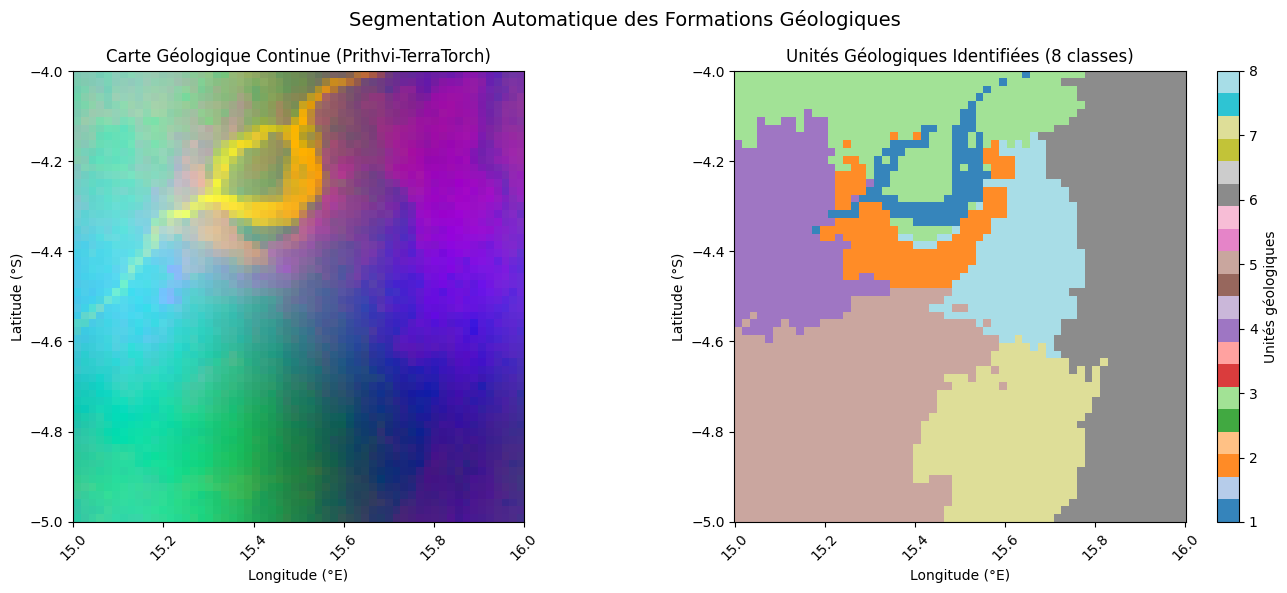


📊 Distribution des formations:
   Unité  1:   3.2% █
   Unité  2:   5.3% ██
   Unité  3:  13.1% ██████
   Unité  4:  10.6% █████
   Unité  5:  22.3% ███████████
   Unité  6:  25.0% ████████████
   Unité  7:  11.8% █████
   Unité  8:   8.8% ████


In [ ]:
# ====================================================
# CELLULE 10: CLASSIFICATION DES UNITÉS GÉOLOGIQUES
# ====================================================
# Segmentation non-supervisée
features_for_clustering = feature_grid.reshape(-1, feature_grid.shape[-1])

# Clustering hiérarchique
n_clusters = 8
dist_matrix = pdist(features_for_clustering, metric='cosine')
linkage_matrix = linkage(dist_matrix, method='ward')
geological_units = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
geological_map_segmented = geological_units.reshape(grid_size, grid_size)

# Visualisation
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Définir l'étendue géographique pour les plots
map_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

ax[0].imshow(geological_map, extent=map_extent)
ax[0].set_title('Carte Géologique Continue (Prithvi-TerraTorch)', fontsize=12)
ax[0].set_xlabel('Longitude (°E)')
ax[0].set_ylabel('Latitude (°S)')
ax[0].tick_params(axis='x', rotation=45)

im = ax[1].imshow(geological_map_segmented, cmap='tab20', alpha=0.9, extent=map_extent)
ax[1].set_title(f'Unités Géologiques Identifiées ({n_clusters} classes)', fontsize=12)
ax[1].set_xlabel('Longitude (°E)')
ax[1].set_ylabel('Latitude (°S)')
ax[1].tick_params(axis='x', rotation=45)
plt.colorbar(im, ax=ax[1], label='Unités géologiques')

plt.suptitle('Segmentation Automatique des Formations Géologiques', fontsize=14)
plt.tight_layout()
plt.show()

# Statistiques
unique_units, counts = np.unique(geological_units, return_counts=True)
print("\n📊 Distribution des formations:")
for unit, count in zip(unique_units, counts):
    pct = (count / geological_map_segmented.size) * 100
    bar = '█' * int(pct/2)
    print(f"   Unité {unit:2d}: {pct:5.1f}% {bar}")

### Affichage des Résultats sur une Carte Interactive Folium
Ce bloc de code utilise la bibliothèque `folium` pour créer une carte interactive. Il superpose plusieurs couches d'information sur une basemap OpenStreetMap:
1.  **La zone d'étude (ROI)**: Délimitée en rouge.
2.  **Image Satellite (RGB Vrai)**: La couche d'image satellite originale.
3.  **Carte Géologique (Prithvi PCA)**: La visualisation RGB des caractéristiques Prithvi.
4.  **Unités Géologiques Segmentées**: La carte des unités géologiques classifiées, avec des couleurs discrètes provenant de la palette `tab20` pour correspondre aux graphiques.

Une fonction utilitaire `array_to_b64_image` convertit les tableaux NumPy en images encodées en base64, ce qui permet à `folium` de les afficher comme des superpositions. Un contrôle de couche est ajouté pour permettre à l'utilisateur de basculer entre les différentes couches.

In [ ]:
# ====================================================
# CELLULE 12: SAUVEGARDE DES RÉSULTATS
# ====================================================
from PIL import Image
import json
from datetime import datetime

# Sauvegarde de la carte
Image.fromarray(geological_map).save('carte_geologique_terratorch.png')
print("💾 Sauvegardé: carte_geologique_terratorch.png")

# Métadonnées complètes
results = {
    'modele': 'Prithvi-EO-2.0-300M',
    'framework': 'TerraTorch',
    'fournisseur': 'NASA/IBM',
    'date_analyse': datetime.now().isoformat(),
    'region': {
        'lon_min': bounds.left,
        'lon_max': bounds.right,
        'lat_min': bounds.bottom,
        'lat_max': bounds.top
    },
    'resolution': f'{grid_size}x{grid_size}',
    'unites_geologiques': len(unique_units),
    'distribution': {f'Unite_{u}': float(count/geological_map_segmented.size)
                     for u, count in zip(unique_units, counts)},
    'features_shape': list(features.shape),
    'pca_variance': pca.explained_variance_ratio_.tolist()
}

with open('resultats_terratorch.json', 'w') as f:
    json.dump(results, f, indent=2)
print("💾 Sauvegardé: resultats_terratorch.json")

print("\n" + "="*70)
print("✅ ANALYSE TERMINÉE - RÉSUMÉ TERRATORCH")
print("="*70)
print(f"🎯 Modèle: Prithvi EO 2.0 (300M paramètres)")
print(f"🔧 Framework: TerraTorch (gestion automatique)")
print(f"🗺️  Zone: {bounds.left:.2f}°E à {bounds.right:.2f}°E, "
      f"{bounds.bottom:.2f}°S à {bounds.top:.2f}°S")
print(f"🔬 Unités géologiques: {len(unique_units)}")
print(f"📐 Variance expliquée par PCA: {pca.explained_variance_ratio_[0]:.1%}")

print("\n🎯 AVEC TERRATORCH, VOUS AVEZ:")
print("✓ Code plus simple et plus robuste")
print("✓ Gestion automatique des dimensions")
print("✓ Possibilité d'ajouter facilement un décodeur")
print("✓ Fine-tuning possible sans refactorisation")
print("\n🌟 La carte générée montre la structure géologique profonde")
print("   extraite automatiquement par l'IA sans entraînement spécifique!")

💾 Sauvegardé: carte_geologique_terratorch.png
💾 Sauvegardé: resultats_terratorch.json

✅ ANALYSE TERMINÉE - RÉSUMÉ TERRATORCH
🎯 Modèle: Prithvi EO 2.0 (300M paramètres)
🔧 Framework: TerraTorch (gestion automatique)
🗺️  Zone: 15.00°E à 16.00°E, -5.00°S à -4.00°S
🔬 Unités géologiques: 8
📐 Variance expliquée par PCA: 17.1%

🎯 AVEC TERRATORCH, VOUS AVEZ:
✓ Code plus simple et plus robuste
✓ Gestion automatique des dimensions
✓ Possibilité d'ajouter facilement un décodeur
✓ Fine-tuning possible sans refactorisation

🌟 La carte générée montre la structure géologique profonde
   extraite automatiquement par l'IA sans entraînement spécifique!


### Calcul de la Superficie des Unités Géologiques
Ce code calcule la superficie, en kilomètres carrés, de chaque unité géologique identifiée. Il commence par estimer l'aire totale de la zone d'étude en se basant sur les coordonnées géographiques. Ensuite, il détermine l'aire couverte par un seul pixel géologique. Enfin, il multiplie le nombre de pixels pour chaque unité par l'aire d'un pixel pour obtenir la superficie totale de cette unité, et affiche les résultats de manière structurée.

Map saved to geological_map.html for external viewing if needed.



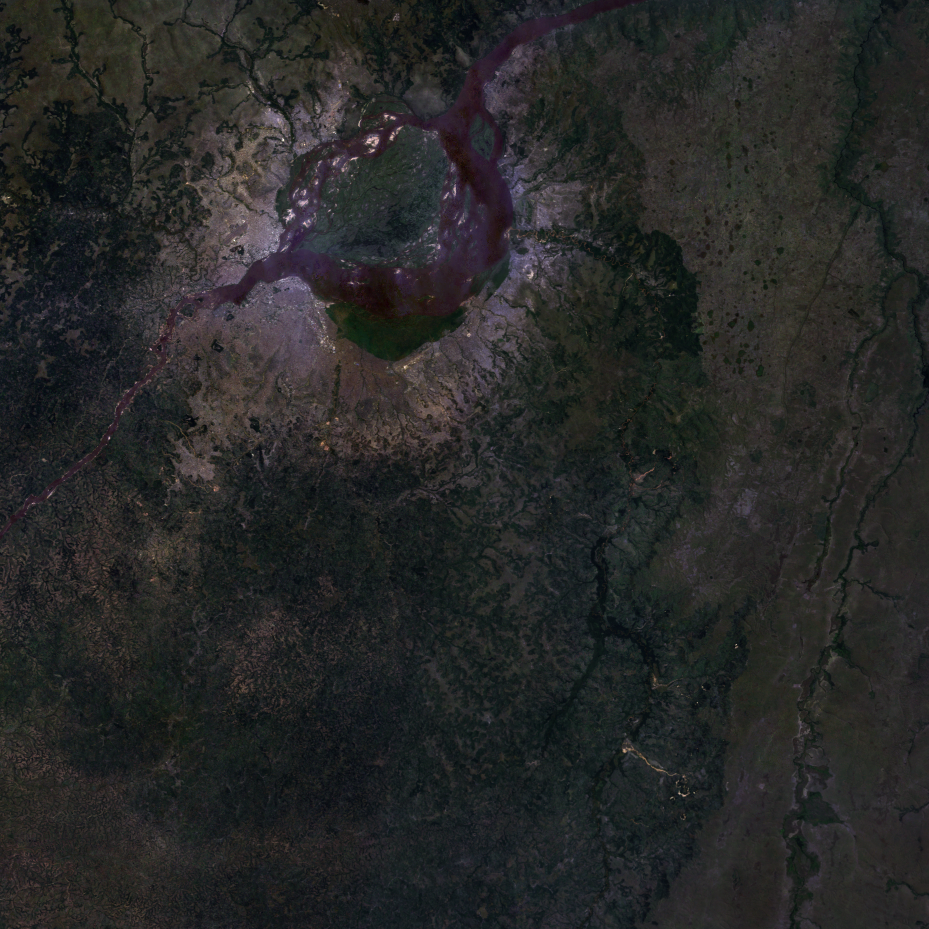
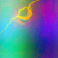
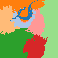

In [ ]:
import folium
from folium.raster_layers import ImageOverlay
import io
import base64
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML # Added for displaying saved HTML maps
import os # Added for file path operations

# Helper function to convert a numpy array to a base64 encoded PNG image for Folium
def array_to_b64_image(arr, is_normalized_0_1=False, cmap=None, is_categorical_map=False):
    if arr.ndim == 2: # Single channel
        if cmap is None:
            cmap = plt.cm.viridis # Default colormap for continuous data

        if is_categorical_map:
            # For categorical maps, arr contains integer labels (e.g., 1, 2, ..., N)
            # We need to map each label directly to a discrete color from the colormap
            unique_labels = np.unique(arr)

            # Create an empty RGBA array to store the colored image
            rgb_image = np.zeros((*arr.shape, 4)) # RGBA

            for label_val in unique_labels:
                # Get the color for this label from the colormap
                # We assume labels are 1-indexed and map them to 0-indexed colors
                # Use modulo 20 for tab20, in case of more than 20 units
                color_index = (label_val - 1) % 20
                color = cmap(color_index)

                # Assign this color to all pixels corresponding to this label
                rgb_image[arr == label_val] = color

            img_to_save = Image.fromarray((rgb_image * 255).astype(np.uint8))

        else: # Continuous 2D data
            norm = plt.Normalize(vmin=np.min(arr), vmax=np.max(arr))
            rgba_img = cmap(norm(arr))
            img_to_save = Image.fromarray((rgba_img * 255).astype(np.uint8))
    elif arr.ndim == 3: # RGB image
        if is_normalized_0_1:
            # Convert 0-1 normalized float array to 0-255 uint8
            img_to_save = Image.fromarray((arr * 255).astype(np.uint8))
        else:
            # Assume already 0-255 uint8 or similar range that can be directly converted
            img_to_save = Image.fromarray(arr.astype(np.uint8))
    else:
        raise ValueError("Unsupported array dimension for image conversion")

    f = io.BytesIO()
    img_to_save.save(f, 'png')
    return base64.b64encode(f.getvalue()).decode()

# Convert the map extent to Folium's bounds format: [[min_lat, min_lon], [max_lat, max_lon]]
folium_bounds = [[bounds.bottom, bounds.left], [bounds.top, bounds.right]]

# Get centroid for initial map centering
roi_centroid = roi.centroid().getInfo()['coordinates']

# Create a base map centered on the ROI with OpenStreetMap tiles
m = folium.Map(location=[roi_centroid[1], roi_centroid[0]],
               zoom_start=9,
               tiles='OpenStreetMap')

# Add original ROI as a GeoJson layer
folium.GeoJson(roi.getInfo(), name='Zone d\'étude', style_function=lambda x: {'color': 'red', 'weight': 2, 'fillOpacity': 0}).add_to(m)

# Add satellite imagery as a layer (True Color RGB)
# rgb_true is normalized 0-1, so set is_normalized_0_1=True
img_b64_true_color = array_to_b64_image(rgb_true, is_normalized_0_1=True)
ImageOverlay(
    image=f'data:image/png;base64,{img_b64_true_color}',
    bounds=folium_bounds,
    name='Image Satellite (RGB Vrai)',
    opacity=1.0,
    control=True
).add_to(m)

# Add the geological map (PCA RGB) as a layer
# geological_map is already uint8, so is_normalized_0_1=False (default is fine)
img_b64_geological_pca = array_to_b64_image(geological_map)
ImageOverlay(
    image=f'data:image/png;base64,{img_b64_geological_pca}',
    bounds=folium_bounds,
    name='Carte Géologique (Prithvi PCA)',
    opacity=0.7, # Make it slightly transparent to see base map
    control=True
).add_to(m)

# Add the segmented geological map as a layer
# geological_map_segmented is a 2D array of cluster labels. Use 'tab20' colormap.
img_b64_geological_segmented = array_to_b64_image(geological_map_segmented, cmap=plt.cm.tab20, is_categorical_map=True)
ImageOverlay(
    image=f'data:image/png;base64,{img_b64_geological_segmented}',
    bounds=folium_bounds,
    name=f'Unités Géologiques Segmentées ({n_clusters} classes)',
    opacity=0.7,
    control=True
).add_to(m)

# Add additional tile layers for more options
folium.TileLayer('Esri.WorldImagery', name='Image Satellite Esri', control=True).add_to(m)
folium.TileLayer('CartoDB dark_matter', name='CartoDB Dark Matter', control=True).add_to(m)

# Add a layer control to toggle between layers
folium.LayerControl().add_to(m)

# Save the map to an HTML file (optional, but good for backup/external viewing)
map_filename = 'geological_map.html'
m.save(map_filename)
print(f"Map saved to {map_filename} for external viewing if needed.")

# Display the map directly in the notebook output
m # This line will trigger the rich display of the Folium map object.

In [ ]:
import math

# Calculate the total area of the ROI in square kilometers
# Convert degrees to kilometers (approximate, for small areas)
# 1 degree of latitude is approximately 111 km
# 1 degree of longitude is approximately 111 * cos(latitude) km

# Average latitude of the ROI for a better approximation
avg_lat = (bounds.bottom + bounds.top) / 2
lat_deg_to_km = 111.0
lon_deg_to_km = 111.0 * math.cos(math.radians(avg_lat))

width_km = (bounds.right - bounds.left) * lon_deg_to_km
height_km = (bounds.top - bounds.bottom) * lat_deg_to_km

total_area_km2 = width_km * height_km
print(f"Total ROI Area: {total_area_km2:.2f} km²")

# Calculate the area per pixel in the geological map
pixel_area_km2 = total_area_km2 / (grid_size * grid_size)
print(f"Area per geological pixel: {pixel_area_km2:.4f} km²/pixel")

# Calculate the area for each geological unit
unit_areas_km2 = {}
print("\n📊 Geological Unit Areas (km²):")
for unit, count in zip(unique_units, counts):
    area_km2 = count * pixel_area_km2
    unit_areas_km2[f'Unite_{unit}'] = area_km2
    print(f"   Unité {unit:2d}: {area_km2:.2f} km²")

Total ROI Area: 12318.46 km²
Area per geological pixel: 3.6619 km²/pixel

📊 Geological Unit Areas (km²):
   Unité  1: 391.82 km²
   Unité  2: 655.47 km²
   Unité  3: 1611.21 km²
   Unité  4: 1307.28 km²
   Unité  5: 2742.73 km²
   Unité  6: 3075.95 km²
   Unité  7: 1453.75 km²
   Unité  8: 1080.25 km²


### Visualisation des Aires des Unités Géologiques (Diagramme à Barres)
Ce code génère un diagramme à barres montrant la superficie de chaque unité géologique en kilomètres carrés. Il utilise les données calculées précédemment et applique la même palette de couleurs (`shared_tab20_colors`) que celle utilisée pour la carte segmentée, garantissant une cohérence visuelle. Des étiquettes de pourcentage sont également ajoutées au-dessus de chaque barre pour indiquer la proportion de chaque unité par rapport à la zone totale.

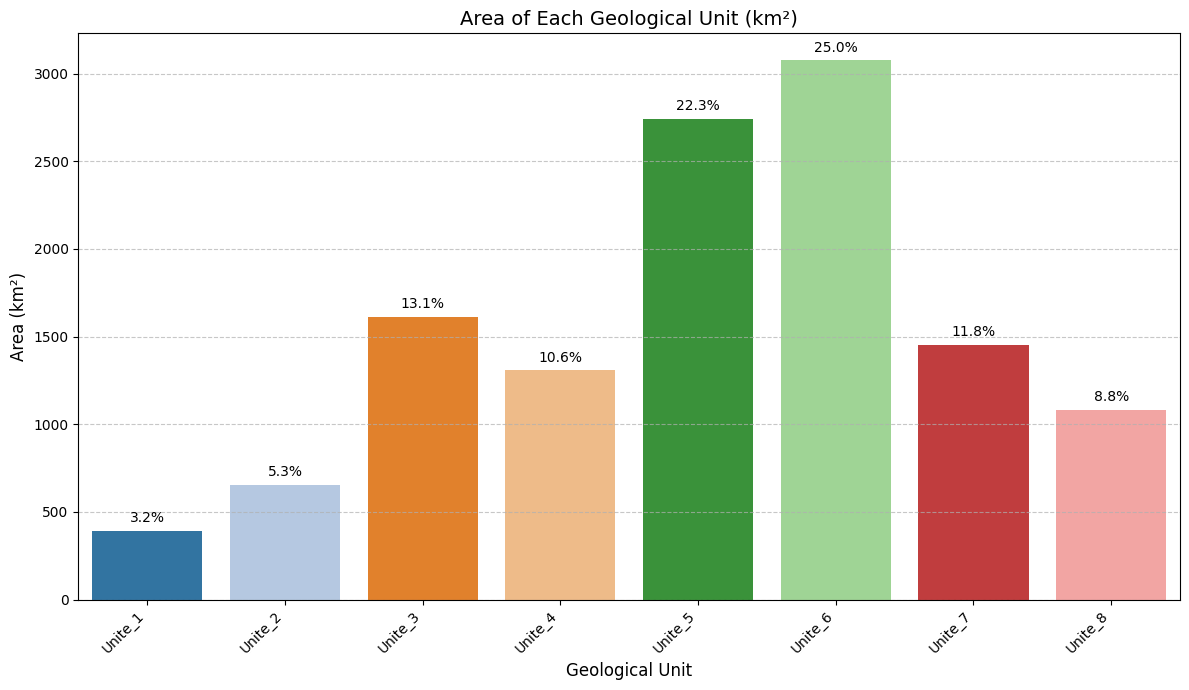

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
unit_names = list(unit_areas_km2.keys())
areas_km2 = list(unit_areas_km2.values())

df_units = pd.DataFrame({
    'Geological Unit': unit_names,
    'Area (km²)': areas_km2
})

# Calculate percentages for labels
total_area = df_units['Area (km²)'].sum()
df_units['Percentage'] = (df_units['Area (km²)'] / total_area) * 100

# Explicitly create a dictionary mapping 'Geological Unit' strings to colors
# Ensure the mapping uses the same logic as the segmented map (unit ID -> tab20 color index)
color_map_dict = {}
for i, unit_name in enumerate(unit_names):
    # unit_name is like 'Unite_1', 'Unite_2', etc.
    # Extract the numerical part, which is the unit ID
    unit_id = int(unit_name.split('_')[1])
    # Map unit ID to tab20 color index (0-indexed)
    # Use modulo 20 for tab20, in case of more than 20 units (though unlikely here)
    color_map_dict[unit_name] = plt.cm.tab20((unit_id - 1) % 20)

# Create the bar plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Geological Unit', y='Area (km²)', data=df_units, palette=color_map_dict)
plt.title('Area of Each Geological Unit (km²)', fontsize=14)
plt.xlabel('Geological Unit', fontsize=12)
plt.ylabel('Area (km²)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on top of the bars
for index, row in df_units.iterrows():
    ax.text(index, row['Area (km²)'] + (ax.get_ylim()[1] * 0.01),
            f'{row["Percentage"]:.1f}%',
            color='black', ha="center", va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Visualisation de la Distribution des Unités Géologiques (Diagramme Circulaire)
Ce code crée un diagramme circulaire (pie chart) pour illustrer la distribution proportionnelle des différentes unités géologiques par superficie. Il utilise les pourcentages calculés précédemment et applique la même palette de couleurs (`shared_tab20_colors`) pour que le graphique soit visuellement cohérent avec les autres représentations. Chaque segment du graphique est étiqueté avec le nom de l'unité et son pourcentage correspondant.

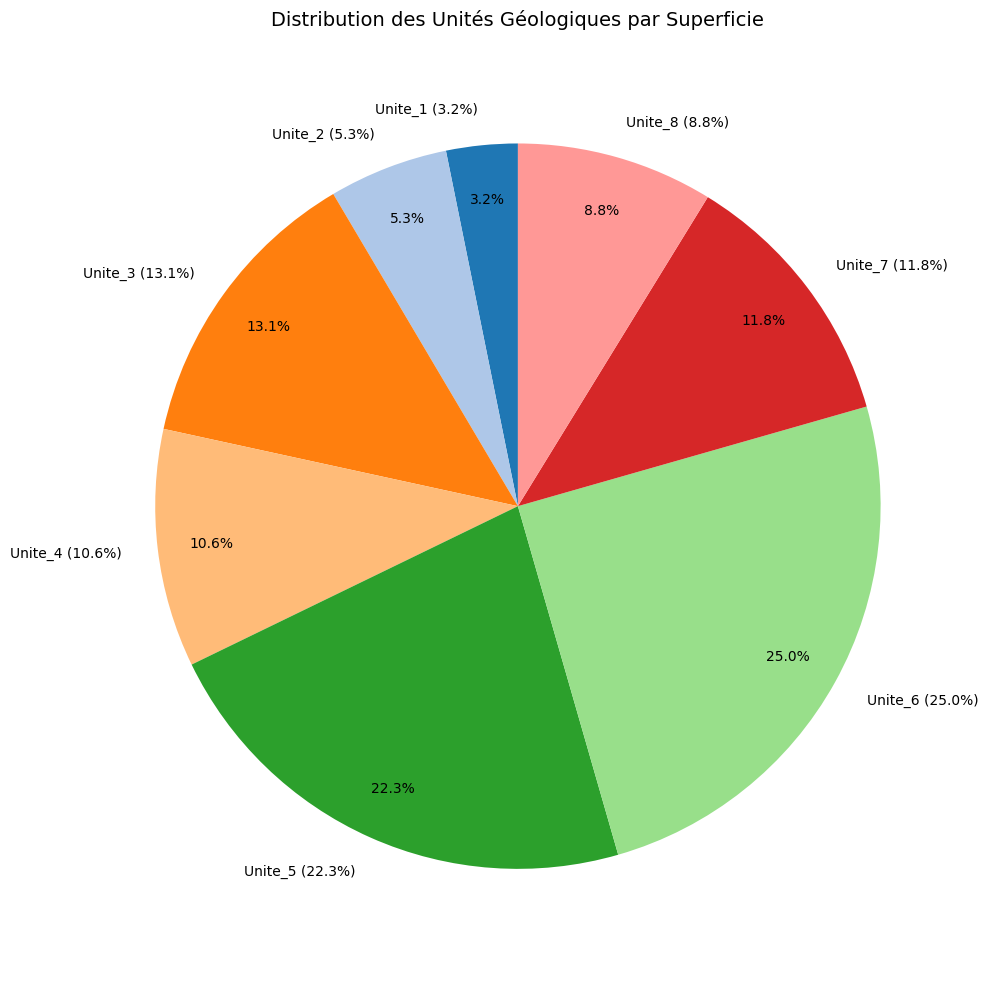

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for the pie chart
pie_labels = df_units['Geological Unit'] + ' (' + df_units['Percentage'].round(1).astype(str) + '%)'
pie_sizes = df_units['Area (km²)']

# Use the same color mapping dictionary created for the bar plot
# Ensure the order of colors matches the order of units in pie_labels/pie_sizes
pie_colors = [color_map_dict[unit_name] for unit_name in df_units['Geological Unit']]

# Create the pie chart
plt.figure(figsize=(10, 10))
plt.pie(pie_sizes, labels=pie_labels, colors=pie_colors, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Distribution des Unités Géologiques par Superficie', fontsize=14)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

### Sauvegarde des Résultats de l'Analyse
Ce bloc de code est responsable de la sauvegarde des produits de l'analyse. Il enregistre la carte géologique générée par TerraTorch sous forme d'image PNG (`carte_geologique_terratorch.png`). De plus, il collecte un ensemble complet de métadonnées de l'analyse (informations sur le modèle, la région, la résolution, la distribution des unités, etc.) et les sauvegarde dans un fichier JSON (`resultats_terratorch.json`). Ces fichiers permettent de documenter et de partager les résultats de l'analyse de manière standardisée.